<a href="https://colab.research.google.com/github/fabiofariasss/fiap-room-reservation-system/blob/Colab/Vers%C3%A3o_Colab_Checkpoint_1_%7C_Eng_Software.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏫 **FIAP Room Reservation System**

#### ***Descrição:***

É um sistema de reserva de salas desenvolvido em Python que funciona via terminal. Ele permite ao usuário visualizar as salas disponíveis, listar todas as reservas já feitas, realizar novas reservas e cancelar reservas existentes. <br>
As informações são armazenadas em um arquivo JSON, garantindo que os dados sejam mantidos mesmo após o programa ser encerrado.
<br>
<br>
Além disso, o sistema realiza validações básicas, como impedir reservas em horários já ocupados e verificar se os dados foram preenchidos corretamente. Tudo isso é acessado por meio de um menu interativo simples.
<br>
<br>
<br>

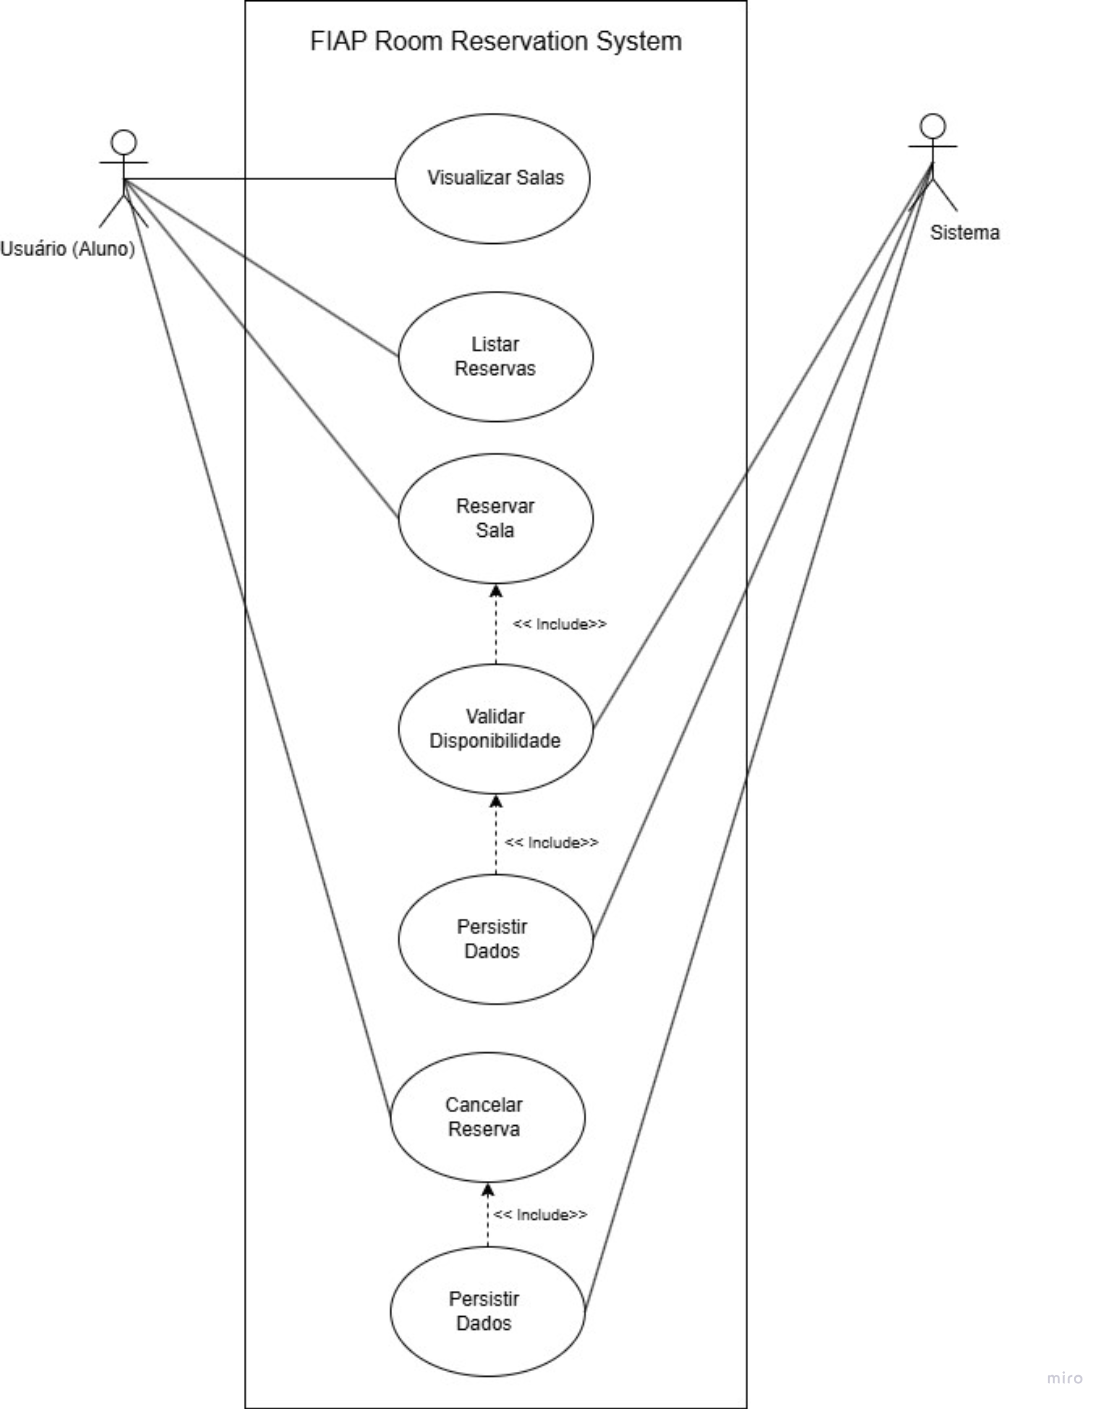

In [7]:
import json
import os

ARQUIVO = "data/reservas.json"

# =========================
# UTILIDADES
# =========================

def carregar_reservas():
    if not os.path.exists(ARQUIVO):
        return []
    with open(ARQUIVO, "r") as f:
        return json.load(f)


def salvar_reservas(reservas):
    os.makedirs("data", exist_ok=True)
    with open(ARQUIVO, "w") as f:
        json.dump(reservas, f, indent=4)


# =========================
# CASOS DE USO
# =========================

def visualizar_salas():
    print("\n📌 Salas disponíveis:")
    print("📚 Sala 1")
    print("📚 Sala 2")
    print("📚 Sala 3")


def listar_reservas(reservas):
    print("\n📋 Reservas:")
    if not reservas:
        print("Nenhuma reserva encontrada.")
        return

    for r in reservas:
        print(f"Nome: {r['nome']} | Sala: {r['sala']} | Horário: {r['horario']}")


def validar_disponibilidade(reservas, sala, horario):
    for r in reservas:
        if r["sala"] == sala and r["horario"] == horario:
            return False
    return True


def reservar_sala(reservas):
    print("\n📝 Nova Reserva")

    nome = input("Digite seu nome: ").strip()
    sala = input("Digite a sala: ").strip()
    horario = input("Digite o horário: ").strip()

    # validação de entrada
    if not nome or not sala or not horario:
        print("\n❌ Dados inválidos!")
        return

    # valida disponibilidade
    if not validar_disponibilidade(reservas, sala, horario):
        print("\n❌ Sala já reservada nesse horário!")
        return

    reservas.append({
        "nome": nome,
        "sala": sala,
        "horario": horario
    })

    salvar_reservas(reservas)
    print("\n✅ Reserva realizada com sucesso!")


def cancelar_reserva(reservas):
    print("\n❌ Cancelar Reserva")

    nome = input("Digite seu nome: ").strip()

    for r in reservas:
        if r["nome"] == nome:
            reservas.remove(r)
            salvar_reservas(reservas)
            print("\n✅ Reserva cancelada!")
            return

    print("\n❌ Nenhuma reserva encontrada para esse nome.")


# =========================
# MENU
# =========================

def menu():
    reservas = carregar_reservas()

    while True:
        print("\n🏫 Sistema de Reserva de Salas\n")
        print("1 - Visualizar salas")
        print("2 - Listar reservas")
        print("3 - Reservar sala")
        print("4 - Cancelar reserva")
        print("0 - Sair")

        opcao = input("\nEscolha uma opção: ")

        if opcao == "1":
            visualizar_salas()
        elif opcao == "2":
            listar_reservas(reservas)
        elif opcao == "3":
            reservar_sala(reservas)
        elif opcao == "4":
            cancelar_reserva(reservas)
        elif opcao == "0":
            print("\n⏳ Encerrando sistema...")
            break
        else:
            print("❌ Opção inválida!")


if __name__ == "__main__":
    menu()


🏫 Sistema de Reserva de Salas

1 - Visualizar salas
2 - Listar reservas
3 - Reservar sala
4 - Cancelar reserva
0 - Sair

Escolha uma opção: 0

⏳ Encerrando sistema...
